# Feature Engineering

Raw datasets often do not contain all the information required to answer business questions directly.

Feature engineering involves creating new variables from existing data that make analysis more meaningful and easier to interpret.

The features created in this notebook will help evaluate match strategies, team performance, and factors influencing match outcomes.

In [2]:
import pandas as pd
import numpy as np

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

matches['date'] = pd.to_datetime(matches['date'])

In [3]:
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}

matches.replace(team_mapping, inplace=True)
deliveries.replace(team_mapping, inplace=True)

## Feature 1: Toss and Match Win Indicator

Winning the toss is often considered an important advantage in T20 cricket.

To evaluate its impact, a new feature is created that identifies whether the team winning the toss also went on to win the match.

In [4]:
matches['toss_match_win'] = (
    matches['toss_winner'] == matches['winner']
)

In [5]:
matches[['toss_winner','winner','toss_match_win']].head()

,toss_winner,winner,toss_match_win
0,Royal Challengers Bengaluru,Kolkata Knight Riders,False
1,Chennai Super Kings,Chennai Super Kings,True
2,Rajasthan Royals,Delhi Capitals,False
3,Mumbai Indians,Royal Challengers Bengaluru,False
4,Deccan Chargers,Kolkata Knight Riders,False


## Feature 2: Analysis Year

A separate analysis year field is created from the match date.

This feature enables yearly trend analysis and simplifies reporting across seasons.

In [6]:
matches['analysis_year'] = matches['date'].dt.year

## Feature 3: Match Result Category

Match margins can be difficult to interpret directly.

Grouping margins into categories makes it easier to compare close contests against dominant victories.

In [7]:
def margin_category(x):

    if pd.isna(x):
        return 'Unknown'

    elif x <= 10:
        return 'Close Match'

    elif x <= 30:
        return 'Competitive Match'

    else:
        return 'Dominant Win'

In [8]:
matches['margin_category'] = matches['result_margin'].apply(
    margin_category
)

In [9]:
matches[['result_margin','margin_category']].head()

,result_margin,margin_category
0,140.0,Dominant Win
1,33.0,Dominant Win
2,9.0,Close Match
3,5.0,Close Match
4,5.0,Close Match


## Feature 4: Match Outcome Type

IPL matches can be won by runs, wickets, ties, or may end without a result.

Creating a dedicated outcome category simplifies future analysis of match patterns.

In [10]:
matches['match_outcome_type'] = matches['result']

In [12]:
matches['match_outcome_type'].value_counts()

wickets      578
runs         498
tie           14
no result      5
Name: match_outcome_type, dtype: int64

## Feature Engineering Summary

Several new features were created to support downstream analysis.

### Features Created

- Toss and Match Win Indicator
- Analysis Year
- Margin Category
- Match Outcome Type

These variables will be used throughout the project to investigate winning patterns, strategic advantages, and long-term IPL trends.

# Business Question 1

## Does Winning the Toss Improve the Chances of Winning the Match?

One of the most debated topics in T20 cricket is whether winning the toss provides a measurable advantage.

This analysis examines how frequently teams convert a toss win into a match victory.

In [13]:
toss_win_percentage = (
    matches['toss_match_win']
    .value_counts(normalize=True)
    * 100
)

toss_win_percentage

True     50.593607
False    49.406393
Name: toss_match_win, dtype: float64

## Insight

The analysis shows that teams winning the toss also won the match approximately 50.6% of the time.

This result suggests that winning the toss alone does not provide a significant competitive advantage in IPL matches.

If the toss were a major deciding factor, the win percentage would be substantially higher than 50%.

The findings indicate that factors such as team strength, batting performance, bowling effectiveness, and match conditions are likely to have a much greater impact on match outcomes than the toss itself.

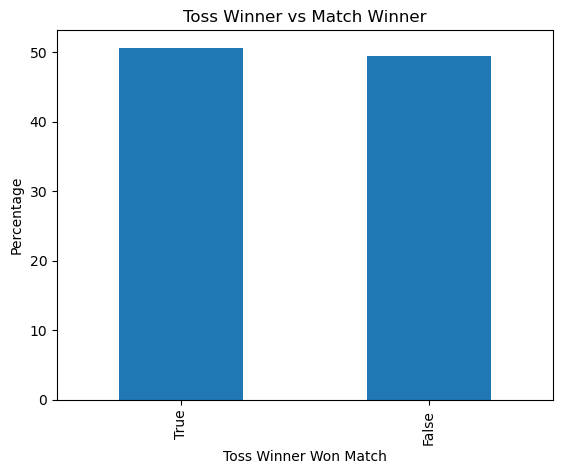

In [14]:
import matplotlib.pyplot as plt

toss_win_percentage.plot(
    kind='bar'
)

plt.title('Toss Winner vs Match Winner')
plt.xlabel('Toss Winner Won Match')
plt.ylabel('Percentage')
plt.show()

# Business Question 2

## Is It Better To Bat First Or Chase?

Teams often debate whether setting a target or chasing one provides a strategic advantage.

This analysis investigates whether teams that choose to bat second achieve better match outcomes compared to teams batting first.

In [17]:
matches['chasing_team_won'] = (
    matches['toss_decision'] == 'field'
)

In [18]:
matches['toss_decision'].value_counts(normalize=True) * 100

field    64.292237
bat      35.707763
Name: toss_decision, dtype: float64

## Chasing Preference Analysis

Captains frequently choose to field first after winning the toss, suggesting a belief that chasing provides a strategic advantage.

The next step is to determine whether this preference is supported by actual match outcomes.

In [19]:
matches['result'].value_counts()

wickets      578
runs         498
tie           14
no result      5
Name: result, dtype: int64

In [20]:
match_results = matches['result'].value_counts()

bat_first_wins = match_results['runs']
chasing_wins = match_results['wickets']

total_completed_matches = bat_first_wins + chasing_wins

print("Bat First Wins:", bat_first_wins)
print("Chasing Wins:", chasing_wins)

print("\nBat First Win %:",
      round((bat_first_wins / total_completed_matches) * 100, 2))

print("Chasing Win %:",
      round((chasing_wins / total_completed_matches) * 100, 2))

Bat First Wins: 498
Chasing Wins: 578

Bat First Win %: 46.28
Chasing Win %: 53.72


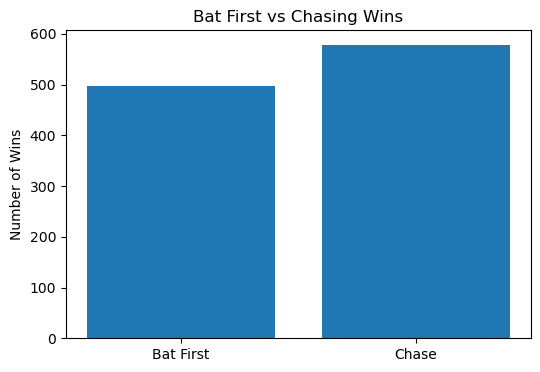

In [21]:
import matplotlib.pyplot as plt

strategy = ['Bat First', 'Chase']
wins = [bat_first_wins, chasing_wins]

plt.figure(figsize=(6,4))
plt.bar(strategy, wins)

plt.title('Bat First vs Chasing Wins')
plt.ylabel('Number of Wins')

plt.show()

## Insight

The analysis shows that teams chasing a target have historically won 53.72% of completed IPL matches, while teams batting first have won 46.28%.

This suggests that chasing provides a measurable advantage in the IPL. The findings support the observed captaincy preference to field first after winning the toss.

Possible reasons include:

- Better visibility of the target score.
- Ability to adjust batting strategy based on match situation.
- Dew factor in night matches improving batting conditions.
- Reduced uncertainty during run chases.

Although the advantage is not overwhelming, the results indicate that chasing has been the more successful strategy across IPL history.

# Business Question 3

## Which Teams Have Won The Most Matches In IPL History?

Understanding franchise-level performance provides insight into long-term competitiveness and consistency across IPL seasons.

This analysis identifies the most successful teams based on total match victories.

In [23]:
team_wins = (
    matches['winner']
    .value_counts()
    .reset_index()
)

team_wins.columns = ['Team', 'Wins']

team_wins.head(10)

,Team,Wins
0,Mumbai Indians,144
1,Chennai Super Kings,138
2,Kolkata Knight Riders,131
3,Royal Challengers Bengaluru,123
4,Delhi Capitals,115
5,Rajasthan Royals,112
6,Punjab Kings,112
7,Sunrisers Hyderabad,88
8,Deccan Chargers,29
9,Gujarat Titans,28


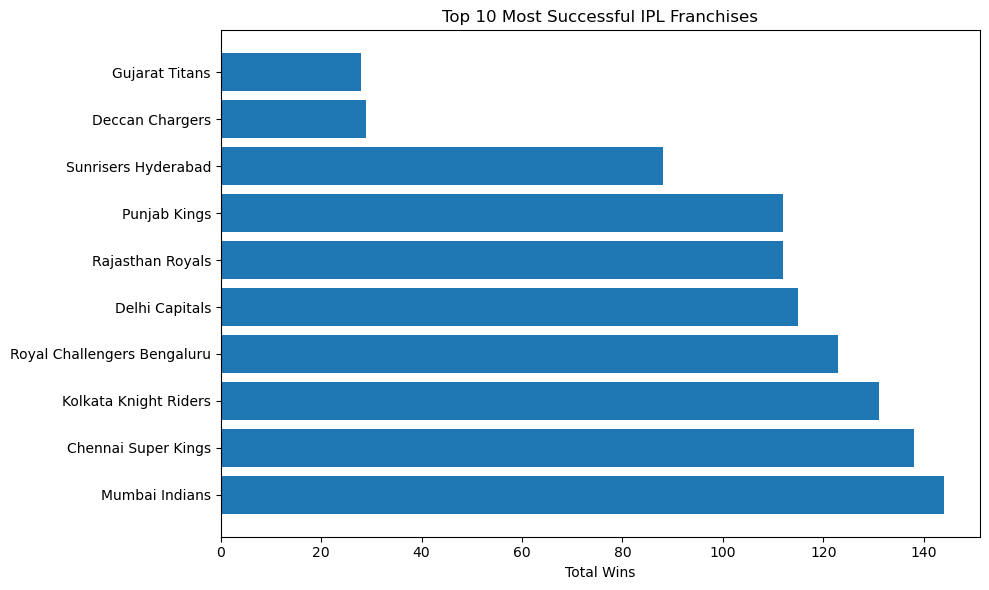

In [25]:
import matplotlib.pyplot as plt

top_10 = team_wins.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_10['Team'],
    top_10['Wins']
)

plt.title('Top 10 Most Successful IPL Franchises')
plt.xlabel('Total Wins')
plt.tight_layout()

plt.show()

## Insight

Mumbai Indians emerge as the most successful franchise in IPL history with 144 victories, followed closely by Chennai Super Kings with 138 wins.

Kolkata Knight Riders and Royal Challengers Bengaluru also rank among the league's most successful teams, demonstrating sustained competitiveness across multiple seasons.

It is important to note that historical franchise name changes were standardized during data preparation. For example:

- Delhi Daredevils and Delhi Capitals were combined.
- Kings XI Punjab and Punjab Kings were combined.
- Royal Challengers Bangalore and Royal Challengers Bengaluru were combined.

This approach provides a more accurate representation of long-term franchise performance.

# Business Question 4

## Which Teams Benefit Most From Winning The Toss?

Although earlier analysis showed that winning the toss has limited overall impact, some franchises may be better at converting toss advantages into match victories.

This analysis evaluates how efficiently teams capitalize on toss wins.

In [26]:
toss_conversion = matches[
    matches['winner'].notna()
].groupby('toss_winner').agg(
    Toss_Wins=('toss_winner', 'count'),
    Match_Wins=('toss_match_win', 'sum')
)

toss_conversion['Conversion_Rate'] = (
    toss_conversion['Match_Wins']
    / toss_conversion['Toss_Wins']
    * 100
)

toss_conversion = (
    toss_conversion
    .sort_values('Conversion_Rate', ascending=False)
)

toss_conversion.head(10)

,Toss_Wins,Match_Wins,Conversion_Rate
toss_winner,,,
Gujarat Lions,15,10,66.666667
Gujarat Titans,22,14,63.636364
Chennai Super Kings,121,75,61.983471
Rising Pune Supergiants,13,8,61.538462
Kolkata Knight Riders,122,68,55.737705
Mumbai Indians,143,78,54.545455
Lucknow Super Giants,19,10,52.631579
Rajasthan Royals,118,60,50.847458
Royal Challengers Bengaluru,120,61,50.833333


In [27]:
reliable_teams = toss_conversion[
    toss_conversion['Toss_Wins'] >= 50
].sort_values(
    'Conversion_Rate',
    ascending=False
)

reliable_teams

,Toss_Wins,Match_Wins,Conversion_Rate
toss_winner,,,
Chennai Super Kings,121,75,61.983471
Kolkata Knight Riders,122,68,55.737705
Mumbai Indians,143,78,54.545455
Rajasthan Royals,118,60,50.847458
Royal Challengers Bengaluru,120,61,50.833333
Delhi Capitals,129,61,47.286822
Sunrisers Hyderabad,88,38,43.181818
Punjab Kings,109,45,41.284404


## Insight

After restricting the analysis to franchises with at least 50 toss wins, Chennai Super Kings emerge as the most effective team at converting toss victories into match wins.

CSK converted approximately 62% of their toss wins into victories, significantly outperforming the overall IPL average.

Mumbai Indians and Kolkata Knight Riders also demonstrate strong conversion rates, suggesting these franchises consistently capitalize on strategic advantages.

In contrast, Punjab Kings and Sunrisers Hyderabad converted fewer than half of their toss wins into victories, indicating that winning the toss alone is insufficient without strong on-field performance.

The findings reinforce an earlier conclusion: team quality and execution appear to matter more than the toss itself.